In [11]:
import torch 
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict  
from ReportPretraining import ReportClassification
from src.layers.transformer.lightcurve import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY


In [12]:
dataset  ='validation'
DEVICE = 'cuda:0'
PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC/class_FL5_baseline_randomwindowmask_nosampler_0_sampler/'
FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"

FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC/class_FL5_baseline_randomwindowmask_nosampler_0_sampler/classifier_ckpt_step=1092.ckpt']
using checkpoint 1092.ckpt
model.ones
model.time_encoder.time_encoders.0.alpha_sin
model.time_encoder.time_encoders.0.alpha_cos
model.time_encoder.time_encoders.0.beta_sin
model.time_encoder.time_encoders.0.beta_cos
model.time_encoder.time_encoders.0.Tmax
model.time_encoder.time_encoders.0.ar
model.time_encoder.time_encoders.0.const
model.time_encoder.time_encoders.0.linear_proj.0.weight
model.time_encoder.time_encoders.0.linear_proj.0.bias
model.time_encoder.time_encoders.1.alpha_sin
model.time_encoder.time_encoders.1.alpha_cos
model.time_encoder.time_encoders.1.beta_sin
model.time_encoder.time_encoders.1.beta_cos
model.time_encoder.time_encoders.1.Tmax
model.time_encoder.time_encoders.1.ar
model.time_encoder.time_encoders.1.const
model.time_encoder.time_encoders.1.linear_proj.0.weight
model.time_encoder.ti

 77%|███████▋  | 147/191 [00:01<00:00, 88.35it/s]

100%|██████████| 191/191 [00:02<00:00, 79.50it/s]


                precision    recall  f1-score   support

           AGN     0.4548    0.3926    0.4214       461
           QSO     0.5911    0.6807    0.6327       429
            EA     0.8406    0.7794    0.8089       467
           YSO     0.5397    0.5680    0.5535       419
          SNIa     0.6455    0.7702    0.7024       383
       CV/Nova     0.6111    0.5356    0.5709       267
          RRLc     0.7002    0.6939    0.6970       441
         RSCVn     0.4512    0.5169    0.4818       385
        Blazar     0.4205    0.3832    0.4010       214
          SNII     0.4660    0.7098    0.5626       193
         EB/EW     0.7071    0.6791    0.6928       455
           LPV     0.8202    0.8166    0.8184       458
           CEP     0.6121    0.5625    0.5862       432
         RRLab     0.6940    0.7790    0.7340       457
Periodic-Other     0.3979    0.3838    0.3907       198
          DSCT     0.4346    0.4328    0.4337       238
         SNIbc     0.2500    0.0149    0.0282  

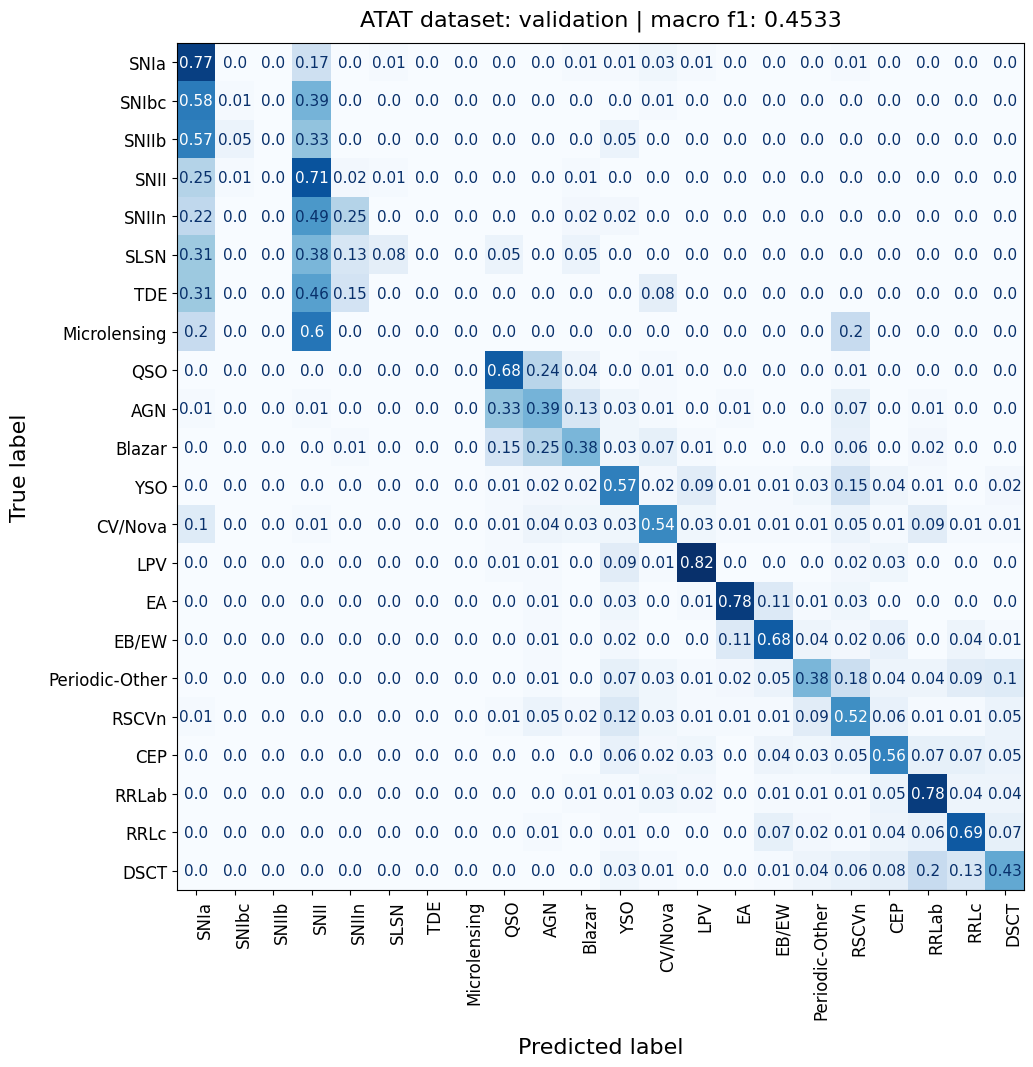

In [13]:
import torchmetrics
test_2 = ReportClassification(
    path_to_training_dir=PATH,
    path_to_dataset= FP_DATASET,
    #path_to_dataset= '/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5',
    model_class = LightCurveTransformer,
    custom_parse_key_str= '',
    model_type = 'lc',
    taxonomy = ZTF_TAXONOMY, #ELASTICC_TAXONOMY,
    device = DEVICE,
    seed = 0,
    figsize = (10,10),
    batch_size=32,
    umap_args={"n_neighbors": 15, "min_dist": 0.05, "metric": "euclidean"},
    marker_size = 6)
report =test_2.classification_report()


0


100%|██████████| 239/239 [00:02<00:00, 81.73it/s]


                precision    recall  f1-score   support

           AGN     0.4574    0.4155    0.4354       556
           QSO     0.5988    0.6807    0.6371       570
            EA     0.7974    0.7667    0.7818       570
           YSO     0.4939    0.5791    0.5331       487
          SNIa     0.6561    0.8103    0.7251       485
       CV/Nova     0.5972    0.5375    0.5658       320
          RRLc     0.6950    0.6782    0.6865       578
         RSCVn     0.4112    0.4955    0.4494       444
        Blazar     0.4273    0.3481    0.3837       270
          SNII     0.5166    0.6825    0.5881       274
         EB/EW     0.7032    0.6436    0.6721       578
           LPV     0.8413    0.8224    0.8317       580
           CEP     0.6135    0.5636    0.5875       566
         RRLab     0.7010    0.7251    0.7128       582
Periodic-Other     0.3278    0.3292    0.3285       240
          DSCT     0.4671    0.4441    0.4553       304
         SNIbc     0.5000    0.0116    0.0227  

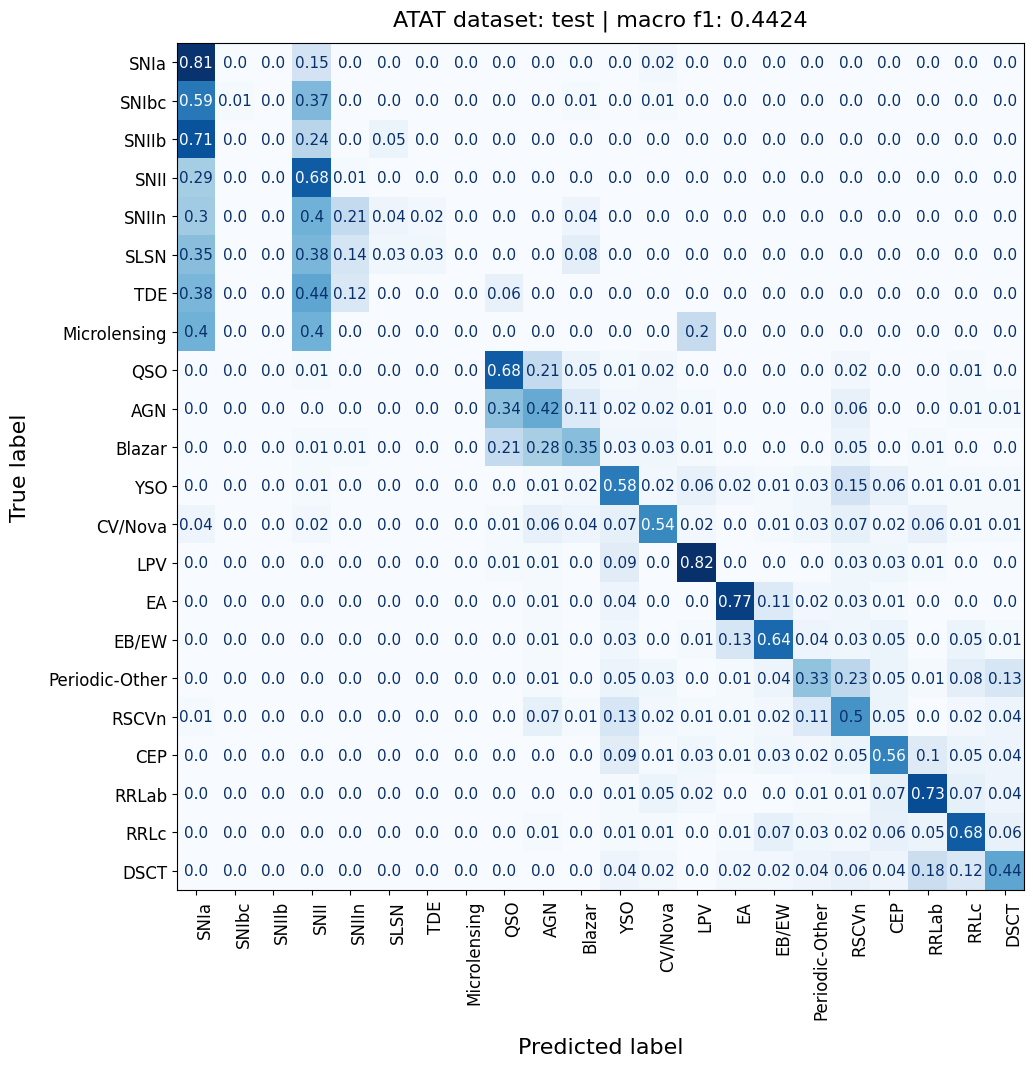

In [14]:
report =test_2.classification_report("test")

In [15]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.20912032124309557
stoch 0.5110185021447109
per 0.6117374466352745


In [16]:
from ReportPretraining import InitBackbone,InitDataLoader, UMAPExplorer, InitClassifier
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier

test = InitClassifier(path_to_config_yaml=PATH, 
                    model= LightCurveTransformer, 
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')
backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)

LightCurveTransformer(
  (time_encoder): TimeHandler(
    (time_encoders): ModuleList(
      (0-1): 2 x TimeFilmModified(
        (linear_proj): Sequential(
          (0): Linear(in_features=1, out_features=128, bias=True)
        )
        (dropout): Dropout(p=0.01, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.01, inplace=False)
  (transformer_lc): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.01, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.01, inplace=False)
        (

In [17]:
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)

0
0
notusingsampler
tensor([0.0022, 0.0026, 0.0026,  ..., 0.0023, 0.0023, 0.0024],
       dtype=torch.float64)
0


In [18]:
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
#dl.set_sampler(True)
X_train, y_train =test.predict(dl.train_dataset, DEVICE)
X_test, y_test =test.predict(dl.validation_dataset, DEVICE)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

device set to cuda:0
LightCurveTransformer(
  (time_encoder): TimeHandler(
    (time_encoders): ModuleList(
      (0-1): 2 x TimeFilmModified(
        (linear_proj): Sequential(
          (0): Linear(in_features=1, out_features=128, bias=True)
        )
        (dropout): Dropout(p=0.01, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.01, inplace=False)
  (transformer_lc): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.01, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.01, inp

 13%|█▎        | 100/763 [00:01<00:07, 84.35it/s]

100%|██████████| 763/763 [00:09<00:00, 82.19it/s]


device set to cuda:0
LightCurveTransformer(
  (time_encoder): TimeHandler(
    (time_encoders): ModuleList(
      (0-1): 2 x TimeFilmModified(
        (linear_proj): Sequential(
          (0): Linear(in_features=1, out_features=128, bias=True)
        )
        (dropout): Dropout(p=0.01, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.01, inplace=False)
  (transformer_lc): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.01, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.01, inp

100%|██████████| 191/191 [00:02<00:00, 80.71it/s]


In [19]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # z = (x - mean) / std
    ('model', KNeighborsClassifier(15,weights='distance'))
])

knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)

classification = classification_report(y_test,knn_preds, target_names=list(ZTF_TAXONOMY().keys()),digits = 4)
print(classification)

                precision    recall  f1-score   support

           AGN     0.4486    0.4642    0.4563       461
           QSO     0.5804    0.6900    0.6305       429
            EA     0.7866    0.7816    0.7841       467
           YSO     0.5013    0.4558    0.4775       419
          SNIa     0.6055    0.8616    0.7112       383
       CV/Nova     0.7076    0.4532    0.5525       267
          RRLc     0.6911    0.7052    0.6981       441
         RSCVn     0.4539    0.4857    0.4693       385
        Blazar     0.5172    0.2804    0.3636       214
          SNII     0.5000    0.5699    0.5327       193
         EB/EW     0.7005    0.6835    0.6919       455
           LPV     0.7318    0.8581    0.7899       458
           CEP     0.6066    0.5532    0.5787       432
         RRLab     0.6917    0.7856    0.7357       457
Periodic-Other     0.3648    0.2929    0.3249       198
          DSCT     0.4402    0.4790    0.4588       238
         SNIbc     0.5000    0.0149    0.0290  

In [20]:
std_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # z = (x - mean) / std
    ('model', LogisticRegression(random_state=0, max_iter = 500, multi_class = 'ovr'))
])

# You can change n_neighbors as needed
std_pipeline.fit(X_train,y_train)
train_y_pred = std_pipeline.predict(X_train)

classification = classification_report(y_train,train_y_pred, target_names=list(ZTF_TAXONOMY().keys()),digits = 4)
#print(classification)
test_y_pred = std_pipeline.predict(X_test)

classification = classification_report(y_test,test_y_pred, target_names=list(ZTF_TAXONOMY().keys()),digits = 4)
print(classification)


                precision    recall  f1-score   support

           AGN     0.4439    0.3601    0.3976       461
           QSO     0.5596    0.7552    0.6429       429
            EA     0.7814    0.8116    0.7962       467
           YSO     0.5794    0.5227    0.5496       419
          SNIa     0.6093    0.8512    0.7102       383
       CV/Nova     0.6205    0.4532    0.5238       267
          RRLc     0.6744    0.7279    0.7001       441
         RSCVn     0.4644    0.4909    0.4773       385
        Blazar     0.4135    0.2570    0.3170       214
          SNII     0.5107    0.6166    0.5587       193
         EB/EW     0.7105    0.7011    0.7058       455
           LPV     0.7708    0.8515    0.8091       458
           CEP     0.5962    0.5880    0.5921       432
         RRLab     0.6709    0.8074    0.7329       457
Periodic-Other     0.4420    0.3081    0.3631       198
          DSCT     0.4559    0.3908    0.4208       238
         SNIbc     0.0000    0.0000    0.0000  

In [21]:
ljlkj

NameError: name 'ljlkj' is not defined

In [ ]:
'''
import numpy as np
import pandas as pd
probs, target = test_1.predict_probs()

review = pd.DataFrame({'is_correct':abs(np.argmax(probs, axis = -1) - target)  == 0,'target':target })
display(review)
def subset_df(subset):

    print(len(subset))

    import h5py
    with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:
        flux_incorrect  = f.get('flux')[subset]
        target_incorrect = f.get('labels')[subset]
    print(flux_incorrect.shape)
    dict_ = {value:key for key, value in ZTF_TAXONOMY().items()}
    df = pd.DataFrame({'obs_count':np.count_nonzero(flux_incorrect, axis = (1,2)), 'target':target_incorrect.astype(int)})
    df['target'] = df['target'].map(dict_)
    df = df.groupby('target').aggregate({'obs_count':list})
    df['incorrect_count'] =  df.obs_count.apply(lambda x: len(x))#.reset_index()
    df['mean'] = df['obs_count'].apply(lambda x: np.mean(x).round(2))
    df['std'] = df['obs_count'].apply(lambda x: np.std(x).round(2))
    df = df.sort_values('incorrect_count', ascending = False)
    return df

subset_df(subset = review.query('is_correct == False').index.tolist())
subset_df(subset = review.query('is_correct == True').index.tolist())
'''

"\nimport numpy as np\nimport pandas as pd\nprobs, target = test_1.predict_probs()\n\nreview = pd.DataFrame({'is_correct':abs(np.argmax(probs, axis = -1) - target)  == 0,'target':target })\ndisplay(review)\ndef subset_df(subset):\n\n    print(len(subset))\n\n    import h5py\n    with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:\n        flux_incorrect  = f.get('flux')[subset]\n        target_incorrect = f.get('labels')[subset]\n    print(flux_incorrect.shape)\n    dict_ = {value:key for key, value in ZTF_TAXONOMY().items()}\n    df = pd.DataFrame({'obs_count':np.count_nonzero(flux_incorrect, axis = (1,2)), 'target':target_incorrect.astype(int)})\n    df['target'] = df['target'].map(dict_)\n    df = df.groupby('target').aggregate({'obs_count':list})\n    df['incorrect_count'] =  df.obs_count.apply(lambda x: len(x))#.reset_index()\n    df['mean'] = df['obs_count'].apply(lambda x: np.mean(x).round(2))\n    df['std'] = df['obs_count'].apply

In [ ]:

def plot_f1(data_dict, taxonomy):

    f1 = []
    for key,value in data_dict.items():
        if key in taxonomy().keys():
            print(key,value)
            f1.append(value['f1-score'])
    print(f1)

    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create a dataframe
    df = pd.DataFrame({'group':taxonomy().keys(), 'values':f1 })
    
    # Reorder it based on the values
    ordered_df = df#.sort_values(by='values')
    my_range=range(1,len(df.index)+1)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range, xmin=0, xmax=ordered_df['values'], color='skyblue')
    plt.plot(ordered_df['values'].values, my_range, "o")
    
    # Add titles and axis names
    plt.yticks(my_range, ordered_df['group'])
    plt.title("F1-Score For Each Class", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(0,1)

    plt.grid('on')
    # Show the plot
    plt.show()

['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/AUGS/LC/class_baseline_3enc/classifier_ckpt_step=2054.ckpt']
using checkpoint 2054.ckpt
model.ones
model.time_encoder.time_encoders.0.alpha_sin
model.time_encoder.time_encoders.0.alpha_cos
model.time_encoder.time_encoders.0.beta_sin
model.time_encoder.time_encoders.0.beta_cos
model.time_encoder.time_encoders.0.Tmax
model.time_encoder.time_encoders.0.ar
model.time_encoder.time_encoders.0.const
model.time_encoder.time_encoders.0.linear_proj.0.weight
model.time_encoder.time_encoders.0.linear_proj.0.bias
model.time_encoder.time_encoders.1.alpha_sin
model.time_encoder.time_encoders.1.alpha_cos
model.time_encoder.time_encoders.1.beta_sin
model.time_encoder.time_encoders.1.beta_cos
model.time_encoder.time_encoders.1.Tmax
model.time_encoder.time_encoders.1.ar
model.time_encoder.time_encoders.1.const
model.time_encoder.time_encoders.1.linear_proj.0.weight
model.time_encoder.time_encoders.1.linear_proj.0.bias
mo

AGN {'precision': 0.44734876773711724, 'recall': 0.18306845965770172, 'f1-score': 0.25981348948167426, 'support': 3272.0}
QSO {'precision': 0.5756471017134525, 'recall': 0.46129126497224654, 'f1-score': 0.512163477132663, 'support': 3423.0}
EA {'precision': 0.8100033568311514, 'recall': 0.6918004587155964, 'f1-score': 0.7462501932890058, 'support': 3488.0}
YSO {'precision': 0.514218009478673, 'recall': 0.4820436875231396, 'f1-score': 0.4976113128224728, 'support': 2701.0}
SNIa {'precision': 0.509493670886076, 'recall': 0.0990159901599016, 'f1-score': 0.16580844490216273, 'support': 1626.0}
CV/Nova {'precision': 0.49934810951760106, 'recall': 0.47696139476961397, 'f1-score': 0.4878980891719745, 'support': 1606.0}
RRLc {'precision': 0.7642357642357642, 'recall': 0.670268691588785, 'f1-score': 0.7141745760074685, 'support': 3424.0}
RSCVn {'precision': 0.45213646902947996, 'recall': 0.5431754874651811, 'f1-score': 0.49349240780911063, 'support': 2513.0}
Blazar {'precision': 0.2350119904076

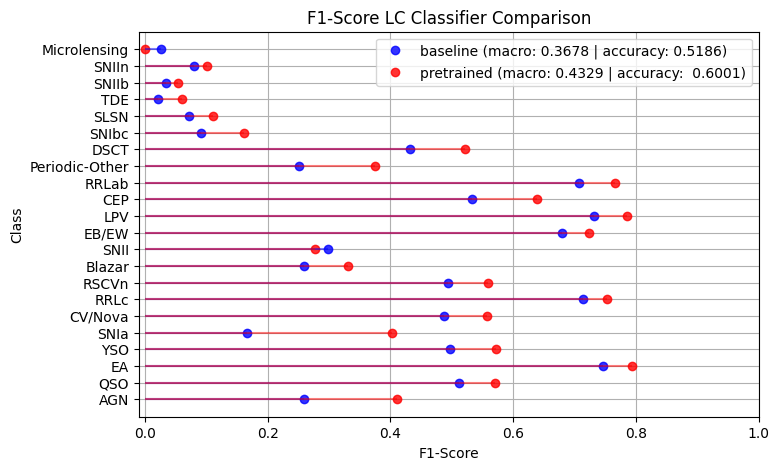

In [ ]:
import pandas as pd
import numpy as np

def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
        print(key,value)
        if key in ZTF_TAXONOMY().keys():
        
            f1_baseline.append(value['f1-score'])
        
    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

group eval:
trans 0.09839675285470709
stoch 0.403280629071823
per 0.5874872458962779


In [ ]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.14604951081213427
stoch 0.4881770963885505
per 0.6572075932640798


In [ ]:
adfadf

NameError: name 'adfadf' is not defined

In [ ]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device(DEVICE))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = DEVICE)  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = DEVICE) for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        #b1['data'][:,before_time:,:] = 0
        #b1['time'][:,before_time:,:] = 0
        #b1['mask'] = (b1['data'] !=0)
        mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [ ]:
data_dict_1['macro avg']['f1-score']

In [ ]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

In [ ]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

modl is not sample dependent